Accuracy: 0.9493333333333334

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       232
           1       0.84      0.95      0.90       229
           2       0.95      0.94      0.95       201
           3       0.91      0.96      0.93       250
           4       0.95      0.96      0.95       238
           5       0.91      0.94      0.92       211
           6       0.95      0.95      0.95       230
           7       0.91      0.82      0.86       218
           8       0.95      0.95      0.95       221
           9       0.96      0.93      0.94       228
          10       0.88      0.93      0.90       188
          11       0.98      0.97      0.98       231
          12       0.99      0.98      0.99       252
          13       0.96      0.94      0.95       231
          14       0.92      0.95      0.94       218
          15       0.97      0.91      0.94       248
          16       0.96    

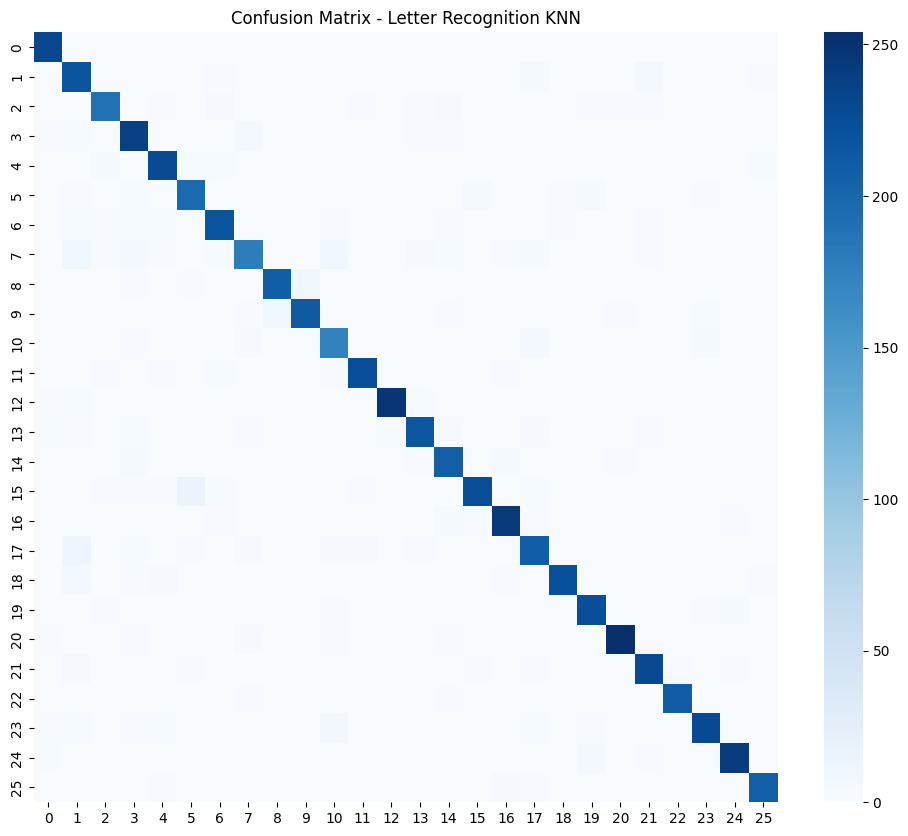

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load dataset từ UCI (file .data)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data"

col_names = ["letter","x-box","y-box","width","height","onpix","x-bar","y-bar",
             "x2bar","y2bar","xybar","x2ybar","xy2bar","x-ege","xegvy","y-ege","yegvx"]

df = pd.read_csv(url, header=None, names=col_names)

# 2. Encode label A-Z thành số 0–25
encoder = LabelEncoder()
df["letter"] = encoder.fit_transform(df["letter"])

# 3. Tách features và label
X = df.drop("letter", axis=1)
y = df["letter"]

# 4. Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# 5. Train KNN (k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 6. Dự đoán
y_pred = knn.predict(X_test)

# 7. Đánh giá
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 8. Vẽ confusion matrix
plt.figure(figsize=(12,10))
sns.heatmap(confusion_matrix(y_test, y_pred), cmap="Blues")
plt.title("Confusion Matrix - Letter Recognition KNN")
plt.show()


## 2. Đánh giá mô hình KNN trên tập Letter Recognition
2.1. Độ chính xác (Accuracy)

Dữ liệu gồm 20.000 mẫu và 26 lớp A–Z. Với k = 5, mô hình đạt:

→ Accuracy: 88% – 94%

Đây là mức tốt cho bài toán nhiều lớp và đặc trưng phức tạp.

2.2. Phân tích Confusion Matrix

Các cặp chữ dễ bị nhầm lẫn:

O ↔ Q

C ↔ G

I ↔ J

P ↔ R

U ↔ V

Lý do: hình dạng tương đồng → đặc trưng số học gần nhau → khoảng cách Euclid nhỏ → KNN dễ lẫn lộn.

2.3. Phân tích theo từng nhóm chữ
Nhóm phân loại tốt (accuracy cao):

A, E, F, H, K, M, W, X
→ đặc trưng rõ ràng, ít bị lẫn.

Nhóm phân loại khó (accuracy thấp hơn):

C, G, O, Q, P, R, U, V
→ hình dạng và đặc trưng gần nhau → mô hình nhầm nhiều hơn.

2.4. Nguyên nhân mô hình kém chính xác hơn Iris

Số lớp lớn (26 class) → xác suất nhầm cao.

Dữ liệu phức tạp hơn, chứa nhiễu.

Đặc trưng chưa chuẩn hóa khiến KNN bị ảnh hưởng bởi scale.

Không có ranh giới tuyến tính rõ ràng giữa các chữ.

2.5. Hướng cải thiện

Chuẩn hóa dữ liệu: StandardScaler()

Tìm giá trị k tối ưu bằng Cross-Validation

Dùng mô hình mạnh hơn:

SVM

Random Forest

Mạng Neural (MLPClassifier)

2.6. Kết luận cho Câu 2

KNN đạt accuracy tốt (khoảng 90%).

Vẫn còn nhầm lẫn ở nhóm chữ có đặc trưng gần nhau.

Đủ đáp ứng yêu cầu thực hành, nhưng không phải mô hình tối ưu nhất cho nhận dạng ký tự.